              precision    recall  f1-score   support

           0       0.87      0.78      0.82      3748
           1       0.69      0.81      0.75      2252

    accuracy                           0.79      6000
   macro avg       0.78      0.80      0.79      6000
weighted avg       0.80      0.79      0.80      6000

ROC-AUC Score: 0.8809003049109909


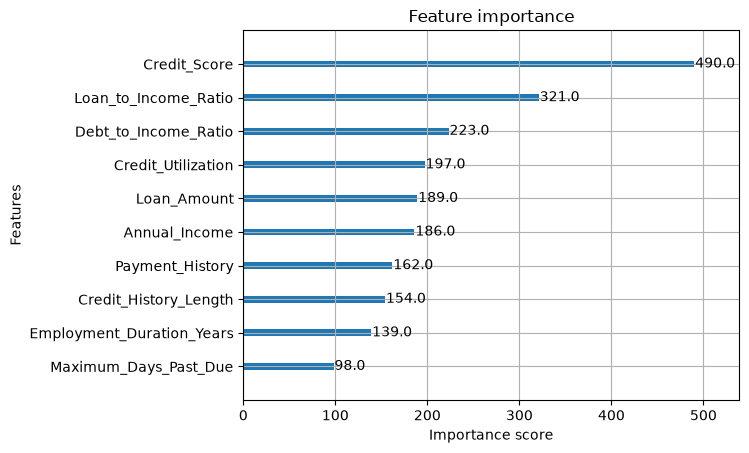

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

# 1. Load dataset and prepare test split
df = pd.read_csv('../data/raw/cleaned_credit_risk_dataset.csv')
X = df.drop(columns=['Decision'])
y = df['Decision'].map({'Approve': 1, 'Reject': 0})
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Load trained model from disk
model = xgb.XGBClassifier()
model.load_model('../models/xgboost_credit_model.json')

# 3. Predict and evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

# 4. Plot feature importance
xgb.plot_importance(model, max_num_features=10)
plt.show()